In [65]:
from langgraph.graph import StateGraph, END,START
from typing import TypedDict
from pydantic import BaseModel, Field
from langchain_google_genai import ChatGoogleGenerativeAI
import httpx
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
def print_workflow_info(workflow, app=None):
    """Prints comprehensive information about a LangGraph workflow."""
    print("WORKFLOW INFORMATION")
    print("====================")
    print(f"Nodes: {workflow.nodes}")
    print(f"Edges: {workflow.edges}")

    
    # Use getter method for finish points if available
    try:
        finish_points = workflow.finish_points
        print(f"Finish points: {finish_points}")
    except:
        try:
            # Alternative approaches
            print(f"Finish point: {workflow._finish_point}")
        except:
            print("Finish points attribute not directly accessible")
    
    if app:
        print("\nWorkflow Visualization:")
        from IPython.display import display
        display(app.get_graph().draw_png())

In [4]:
client = httpx.Client(verify=False)

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [5]:
class ChainState(TypedDict):
    job_description: str
    resume_summary: str
    cover_letter: str

Resume Summary Agent

In [6]:
def generate_resume_summary(state: ChainState) -> ChainState:
    prompt = f"""
        You're a resume assistant. Read the following job description and summarize the key qualifications and experience the ideal candidate should have, phrased as if from the perspective of a strong applicant's resume summary.

        Job Description:
        {state['job_description']}
        """
    response = llm.invoke(prompt)
    return {**state, 'resume_summary':response.content}

Generate Cover Letter Agent

In [7]:
def generate_cover_letter(state: ChainState) -> ChainState:
    prompt = f"""
        You're a cover letter writing assistant. Using the resume summary below, write a professional and personalized cover letter for the following job.

        Resume Summary:
        {state['resume_summary']}

        Job Description:
        {state['job_description']}
        """
    response = llm.invoke(prompt)
    return {**state, 'cover_letter': response.content}

Langgraph Workflow

In [8]:
workflow = StateGraph(ChainState)
workflow

In [9]:
workflow.add_node("generate_resume_summary", generate_resume_summary)
workflow.add_node("generate_cover_letter", generate_cover_letter)

In [10]:
workflow.set_entry_point("generate_resume_summary")

In [11]:
workflow.add_edge("generate_resume_summary", "generate_cover_letter")

In [12]:
workflow.set_finish_point("generate_cover_letter")

In [13]:
print_workflow_info(workflow)

WORKFLOW INFORMATION
Nodes: {'generate_resume_summary': StateNodeSpec(runnable=generate_resume_summary(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None, input_schema=<class '__main__.ChainState'>, retry_policy=None, cache_policy=None, is_error_handler=False, error_handler_node=None, ends=(), defer=False, timeout=None), 'generate_cover_letter': StateNodeSpec(runnable=generate_cover_letter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None, input_schema=<class '__main__.ChainState'>, retry_policy=None, cache_policy=None, is_error_handler=False, error_handler_node=None, ends=(), defer=False, timeout=None)}
Edges: {('generate_cover_letter', '__end__'), ('__start__', 'generate_resume_summary'), ('generate_resume_summary', 'generate_cover_letter')}
Finish points attribute not directly accessible


In [14]:
app = workflow.compile()

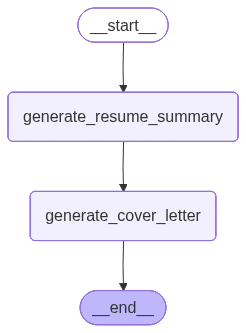

In [15]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [16]:
input_state = {
        "job_description": "We are looking for a data scientist with experience in machine learning, NLP, and Python. Prior work with large datasets and experience deploying models into production is required."
}

result = app.invoke(input_state)

In [17]:
result['resume_summary']

'Highly accomplished Data Scientist specializing in leveraging Machine Learning and Natural Language Processing (NLP) to extract actionable insights, with strong proficiency in Python. Proven expertise in managing and analyzing large datasets and a track record of successfully deploying robust models into production environments.'

Workflow Pattern: Routing

Usecase - Task classifier for Summarization and Translation

In [18]:
class RouterState(TypedDict):
    user_input: str
    task_type: str
    output: str

In [19]:
class Router(BaseModel):
    role: str = Field(..., description="Decide whether the user wants to summarize a passage  ouput 'summarize'  or translate text into French oupput translate.")
llm_router = llm.bind_tools([Router])

In [20]:
response = llm_router.invoke("summarize this I love the sun its so warm")

In [21]:
def router_node(state: RouterState) -> RouterState:
    routing_prompt = f"""
    You are an AI task classifier.
    
    Decide whether the user wants to:
    - "summarize" a passage
    - or "translate" text into French
    
    Respond with just one word: 'summarize' or 'translate'.
    
    User Input: "{state['user_input']}"
    """
    response = llm_router.invoke(routing_prompt)
    return {**state, 'task_type': response.tool_calls[0]['args']['role']}

In [22]:
def router(state: RouterState) -> str:
    return state['task_type']

In [23]:
def summarize_node(state: RouterState) -> RouterState:
    prompt = f"Please summarize the following passage:\n\n{state['user_input']}"
    response = llm_router.invoke(prompt)
    return {**state, 'task_type': 'summarize', 'output': response.content}

In [24]:
def translate_node(state: RouterState) -> RouterState:
    prompt = f"Translate the following text to French:\n\n{state['user_input']}"
    response = llm_router.invoke(prompt)
    return {**state, 'task_type': 'translate', 'output': response.content}

In [25]:
workflow = StateGraph(RouterState)

In [26]:
workflow.add_node("router", router_node)
workflow.add_node("summarize", summarize_node)
workflow.add_node("translate", translate_node)

In [27]:
workflow.set_entry_point("router")

In [28]:
workflow.add_conditional_edges("router", router, {
    "summarize": "summarize",
    "translate": "translate"
})

In [29]:
workflow.set_finish_point("summarize")
workflow.set_finish_point("translate")

In [30]:
app = workflow.compile()

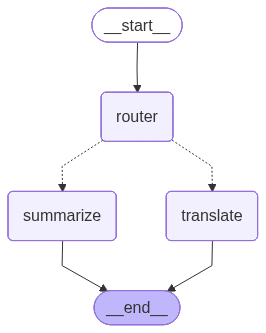

In [31]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [32]:
input_text = {
        "user_input": "Can you translate this sentence: I love programming?"
    }
result = app.invoke(input_text)

In [33]:
print(result[ 'output'])
print(result['task_type'])


translate


In [34]:
input_text = {
        "user_input": "Can you summarize this sentence: I love programming so much it is the best thing ever. All I want to do is programming?"
    }

result = app.invoke(input_text)

In [38]:
print(result[ 'output'])
print(result['task_type'])


summarize


Workflow Pattern - Parallelization

Usecase: Multilingual translation assistant

In [39]:
class State(TypedDict):
    text: str
    french: str
    spanish: str
    japanese: str
    combined_output: str

In [40]:
def translate_french(state: State) -> dict:
    response = llm.invoke(f"Translate the following text to French:\n\n{state['text']}")
    return {"french": response.content.strip()}

In [41]:
def translate_spanish(state: State) -> dict:
    response = llm.invoke(f"Translate the following text to Spanish:\n\n{state['text']}")
    return {"spanish": response.content.strip()}

In [42]:
def translate_japanese(state: State) -> dict:
    response = llm.invoke(f"Translate the following text to Japanese:\n\n{state['text']}")
    return {"japanese": response.content.strip()}

In [43]:
def aggregator(state: State) -> dict:
    combined = f"Original Text: {state['text']}\n\n"
    combined += f"French: {state['french']}\n\n"
    combined += f"Spanish: {state['spanish']}\n\n"
    combined += f"Japanese: {state['japanese']}\n"
    return {"combined_output": combined}

In [44]:
graph = StateGraph(State)

In [45]:
graph.add_node("translate_french", translate_french)
graph.add_node("translate_spanish", translate_spanish)
graph.add_node("translate_japanese", translate_japanese)
graph.add_node("aggregator", aggregator)

In [46]:
graph.add_edge(START, "translate_french")
graph.add_edge(START, "translate_spanish")
graph.add_edge(START, "translate_japanese")

In [47]:
graph.add_edge("translate_french", "aggregator")
graph.add_edge("translate_spanish", "aggregator")
graph.add_edge("translate_japanese", "aggregator")

In [48]:
graph.add_edge("aggregator", END)

In [49]:
app = graph.compile()

In [50]:
input_text = {
        "text": "Good morning! I hope you have a wonderful day."
}

result = app.invoke(input_text)

In [51]:
result

{'text': 'Good morning! I hope you have a wonderful day.',
 'french': "Bonjour ! J'espère que vous passez une merveilleuse journée.",
 'spanish': '¡Buenos días! Espero que tenga un día maravilloso.',
 'japanese': 'Here are a few natural ways to translate that into Japanese, depending on the nuance you prefer:\n\n**Option 1 (Common and direct, using "wonderful"):**\n\n*   **Japanese:** おはようございます！素晴らしい一日をお過ごしください。\n*   **Romaji:** Ohayō gozaimasu! Subarashii ichinichi o osugoshi kudasai.\n*   **Breakdown:**\n    *   おはようございます (Ohayō gozaimasu): Good morning! (polite)\n    *   素晴らしい (Subarashii): Wonderful / Splendid\n    *   一日 (ichinichi): Day\n    *   を (o): Object particle\n    *   お過ごしください (osugoshi kudasai): Please spend / Please have (a polite way to say "have a good time/day")\n\n**Option 2 (Slightly more casual/friendly, using "good day"):**\n\n*   **Japanese:** おはようございます！良い一日を。\n*   **Romaji:** Ohayō gozaimasu! Yoi ichinichi o.\n*   **Breakdown:**\n    *   おはようございます (Ohayō gozai

Building a multi-agent routing system

In [53]:
class RouterState(TypedDict):
    user_input: str
    task_type: str
    output: str

class Router(BaseModel):
    role: str = Field(
        ..., 
        description="Classify the user request. Return exactly one of: 'ride_hailing_call', 'restaurant_order', 'groceries' and if you do not know output 'default_handler'"
    )

llm_router = llm.bind_tools([Router])

In [54]:
def router_node(state: RouterState) -> RouterState:
    response = llm_router.invoke(state['user_input'])

    if response.tool_calls:
        tool_call = response.tool_calls[0]['args']['role']
        return {**state, 'task_type': tool_call}
    else:
        return {**state, 'task_type': 'defalt_handler'}
    
def router(state: RouterState) -> RouterState:
    return state['task_type']

In [56]:
def ride_hailing_node(state: RouterState) -> RouterState:
    prompt = f"""
    You are a ride hailing assistant. Based on the user's request, extract and organize the following information:
    
    - Pickup location
    - Destination/dropoff location  
    - Preferred ride type (if mentioned)
    - Any special requirements
    - Estimated timing preferences
    
    User Request: "{state['user_input']}"
    
    Provide a clear summary of the ride request with all available details.
    """
    response = llm_router.invoke(prompt)
    return {**state, 'task_type': "ride_hailing_call", 'output': response.content.strip()}

In [58]:
def restaurant_order_node(state: RouterState) -> RouterState:
    """
    Processes restaurant orders by organizing menu items, quantities, and preferences
    """
    prompt = f"""
    You are a restaurant ordering assistant. Based on the user's request, organize the following information:
    
    - Menu items requested
    - Quantities for each item
    - Special modifications or dietary restrictions
    - Delivery or pickup preference
    - Any timing requirements
    
    User Request: "{state['user_input']}"
    
    Provide a clear, organized summary of the restaurant order with all details.
    """
    
    response = llm.invoke(prompt)
    
    return {
        **state, 
        "task_type": "restaurant_order", 
        "output": response.content.strip()
    }

In [59]:
def groceries_node(state: RouterState) -> RouterState:
    """
    Processes grocery delivery requests with driver pickup service
    """
    prompt = f"""
    You are a grocery delivery assistant for a service where our drivers pick up groceries for customers.
    
    Based on the user's request, organize the following information:
    
    Shopping List:
    - List of grocery items needed
    - Quantities or amounts for each item
    - Brand preferences (if mentioned)
    - Any dietary restrictions or organic preferences
    
    Store Information:
    - Preferred store or location
    - Budget considerations
    - Special instructions for finding items
    
    Delivery Details:
    - Delivery address (if provided)
    - Preferred delivery time window
    - Any special delivery instructions
    - Contact information for driver coordination
    
    Driver Instructions:
    - Substitution preferences (if item unavailable)
    - How to handle out-of-stock items
    - Any items requiring special handling (fragile, cold items)
    - Payment method (if mentioned)
    
    User Request: "{state['user_input']}"
    
    Provide a comprehensive delivery order summary that our driver can use to efficiently shop and deliver groceries. 
    Include estimated pickup time and any special notes for the shopping trip.
    
    Format the response as a clear, organized delivery order that includes all necessary details for our driver service.
    """
    
    response = llm.invoke(prompt)
    
    return {
        **state, 
        "task_type": "groceries", 
        "output": response.content.strip()
    }

In [60]:
def default_handler_node(state: RouterState) -> RouterState:
    prompt = f"""
    I couldn't classify your request into a specific category. 
    Let me provide general assistance for: "{state['user_input']}"
    
    I can help you with:
    - Ride hailing services
    -  Restaurant orders  
    -  Grocery shopping
    
    Please rephrase your request to match one of these services, or if you need assistance with something else, I will connect you with our customer support team who can provide personalized help.
    
    Would you like me to:
    1. Help you rephrase your request for one of our services
    2. Connect you with customer support for additional assistance
    """
    response = llm.invoke(prompt)
    return {**state, "task_type": "default_handler", "output": response.content.strip()}

In [61]:
workflow = StateGraph(RouterState)

workflow.add_node("router", router_node)
workflow.add_node("ride_hailing_call", ride_hailing_node)
workflow.add_node("restaurant_order", restaurant_order_node)
workflow.add_node("groceries", groceries_node)
workflow.add_node("default_handler", default_handler_node)

workflow.set_entry_point("router")

workflow.add_conditional_edges("router", router, {
    "groceries": "groceries", 
    "restaurant_order": "restaurant_order",
    "ride_hailing_call": "ride_hailing_call",
    "default_handler": "default_handler"
})

workflow.set_finish_point("ride_hailing_call")
workflow.set_finish_point("restaurant_order")
workflow.set_finish_point("groceries")
workflow.set_finish_point("default_handler")

app = workflow.compile()

In [66]:
test_cases = [
    {"user_input": "I need a ride from downtown to the airport at 3pm"},
    {"user_input": "I want to order 2 large pepperoni pizzas for delivery"},
    {"user_input": "I need milk, bread, eggs, and vegetables for the week"},
    {"user_input": "What's the weather like today?"},  # Default/unclassified example
]

for i, test_input in enumerate(test_cases, 1):
    result=app.invoke(test_input)


    print(f"question {test_input["user_input"]}\n")
    print(f"task_type {result['task_type']}\n")
    print(f"output: {result['output']}\n")
    print('-----------------------------------')

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 35.602963698s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT